# Koyna Dam 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import re

import xara
import veux

In [2]:
from pathlib import Path
cwd = Path.cwd()
KOYNA_DIR = cwd

OUT = KOYNA_DIR / 'out' 
OUT.mkdir(parents=True, exist_ok=True)

Import constants to help track units from the {ref}`units` module.

In [3]:

# from xara.units.si import (
#     m,   # meter
#     mm,  # millimeter
#     kg,  # kilogram
#     Pa,
#     MPa,
#     GPa,
#     gravity as g
# )

from xara.units import create_units

units = create_units(length="foot", mass="kg")

GPa = units.GPa
MPa = units.MPa
m   = units.m
kg  = units.kg
kN  = units.kN

print(f"""
Units:
  {m   = }
  {kg  = }
  {kN  = }
  {GPa = }
""")


Units:
  m   = 3.280839895013124
  kg  = 1.0
  kN  = 3280.839895013124
  GPa = 304799999.99999994



The method {ref}`getNodeTags` of {py:class}`xara.Model` returns the tags of all the nodes that have been defined in the model. 

In [4]:
from xara.helpers import find_nodes, find_node

## Modeling

### Parameters

In [5]:
L_base = 70.0 * m
H_base = 66.5 * m
H_top = 36.5 * m
thickness = 1.0
h_water = 91.75 * m

nx = 8 #14 #20
ny_base = 8 #14 # 24
ny_top = 8 #14

Ec = 31.027 * GPa
fc = 24.1 * MPa
ft = 2.9 * MPa
nu = 0.2
rho = 2643.0 * kg / (m ** 3)
rho_water = 1000.0 * kg / (m ** 3)
zeta = 0.03



Begin by creating the basic model components:
- The {py:class}`xara.Model` is the container that holds all model definitions. 
- The {py:class}`xara.MultiaxialMaterial` is defined using the [ElasticIsotropic](https://xara.so/user/manual/material/ndMaterials/ElasticIsotropic.html) formulation
- Finally, {py:class}`xara.PlaneSection` combines the `material` formulation with a 2D constraint to allow it's use with 2D elements.

In [6]:
model = xara.Model(ndm=2, ndf=2)


material = xara.MultiaxialMaterial("ElasticIsotropic",
               E=Ec, 
               G=Ec/(2.0 * (1.0 + nu)),
               density = rho
)
# add the material to the model
model.material(material)


# Create a section to represent the "plane stress" behavior of the
# multiaxial material in a 2D element.
section = xara.PlaneSection("PlaneStress", 
                            thickness=thickness, 
                            material=material)
# Add the section to the model
model.section(section)


### Mesh Generation

The element mesh is generated using the {py:meth}`Model.surface` method.

In [7]:
Element = "Q8"
plane_args = {"section": section, "b": [0.0, -rho*units.gravity]}

base_surface = model.surface(
    (nx, ny_base),
    element=Element,
    args=plane_args,
    points={
        1: (   0.0, 0.0),
        2: (L_base, 0.0),
        3: (19.25 * m, H_base),
        4: (0.0, H_base),
    },
)

crest_surface = model.surface(
    (nx, ny_top),
    element=Element,
    args=plane_args,
    points={
        1: (0.0, H_base),
        2: (19.25 * m, H_base),
        3: (14.8 * m, H_base + H_top),
        4: (0.0, H_base + H_top),
    },
)

# Find all nodes at y=0.0 and fix them in both x and y directions
for tag in find_nodes(model, y=0.0):
    model.fix(tag, 1, 1)

# Find the node at the crest of the dam
crest = find_node(model, y=H_base+H_top, x=0.0)

print(f'Nodes: {len(model.getNodeTags())}')
print(f'Elements: {len(model.getEleTags())}')
print(f'Crest node: {crest}')

artist = veux.create_artist(model, ndf=2)
artist.draw_nodes(size=4)
artist.draw_outlines()
artist

Nodes: 433
Elements: 128
Crest node: 417


## Gravity


In [8]:

def upstream_face_nodes(model):
    return sorted(
        [(tag, model.nodeCoord(tag)) for tag in find_nodes(model, x=0.0)],
        key=lambda item: item[1][1],
    )


def hydrodynamic_loading(model, h_water, rho_water, thickness, gravity):
    face_nodes = upstream_face_nodes(model)
    added_masses = {}
    hydro_loads = {}

    for index, (tag, (_, y)) in enumerate(face_nodes):
        if y > h_water:
            break

        if index == 0:
            tributary = (face_nodes[index + 1][1][1] - y) / 2.0
        elif index == len(face_nodes) - 1:
            tributary = (y - face_nodes[index - 1][1][1]) / 2.0
        else:
            tributary = (face_nodes[index + 1][1][1] - face_nodes[index - 1][1][1]) / 2.0

        mass_per_area = 0.875 * rho_water * np.sqrt(h_water * (h_water - y))
        node_mass = mass_per_area * tributary * thickness
        pressure = rho_water * gravity * (h_water - y)

        added_masses[tag] = (node_mass, 0.0)
        hydro_loads[tag] = (pressure * tributary * thickness, 0.0)

    return added_masses, hydro_loads


In [9]:

added_masses, hydro_loads = hydrodynamic_loading(model, h_water, rho_water, thickness, units.gravity)
for tag, (mx, my) in added_masses.items():
    model.mass(tag, mx, my)



pattern = xara.StaticPattern(xara.NodalLoad(model, hydro_loads))
model.pattern(pattern)


print(f'Upstream water-loaded nodes: {len(hydro_loads)}')

Upstream water-loaded nodes: 28


In [10]:

model.constraints('Plain')
model.numberer('Plain')
model.system('Umfpack')
model.test('EnergyIncr', 1.0e-12, 50)

model.algorithm('Newton')
model.integrator('LoadControl', 1.0)
model.analysis('Static')

static_ok = model.analyze(1)
if static_ok != 0:
    raise RuntimeError(f'Gravity analysis failed with code {static_ok}')


model.loadConst(time=0.0)
print('Gravity analysis completed.')

crest_node = find_node(model, y=H_base+H_top, x=0.0)
crest_disp = model.nodeResponse(crest_node, 1, 'displacement')
crest_disp


Gravity analysis completed.


0.010582670565087644

In [12]:
from xara.post import NodalStress

artist = veux.create_artist(model, canvas="gltf", ndf=2)

artist.draw_outlines()
artist.draw_outlines(state=model.nodeDisp, scale=1/units.mm)
artist.draw_surfaces(state=model.nodeDisp, scale=1/units.mm, field=NodalStress(model, "sxx"))
artist


## Eigenvalues, and Damping

In [13]:

eigenvalues = model.eigen(5)
periods = [2.0 * np.pi / np.sqrt(value) for value in eigenvalues]

omega_1 = np.sqrt(eigenvalues[0])
beta_k = 2.0 * zeta / omega_1
model.rayleigh(0.0, 0.0, 0.0, beta_k)

print('Eigen analysis completed.')
print('First five periods (s):')
for i, period in enumerate(periods, start=1):
    print(f'  Mode {i}: {period:.6e}')
print(f'Stiffness-proportional damping beta_k = {beta_k:.6e}')




Eigen analysis completed.
First five periods (s):
  Mode 1: 3.785812e-01
  Mode 2: 1.499724e-01
  Mode 3: 9.371815e-02
  Mode 4: 7.836500e-02
  Mode 5: 5.273591e-02
Stiffness-proportional damping beta_k = 3.615184e-03


Structural modes are similarly rendered using the {ref}`nodeEigenvector` method.

In [14]:
mode = 2
artist = veux.create_artist(model, ndf=2)

artist.draw_outlines()
artist.draw_outlines(state=lambda n: model.nodeEigenvector(n, mode), scale=10000)
artist

## Transient Analysis


Input duration: 10.000 s
Data time step: 0.010 s


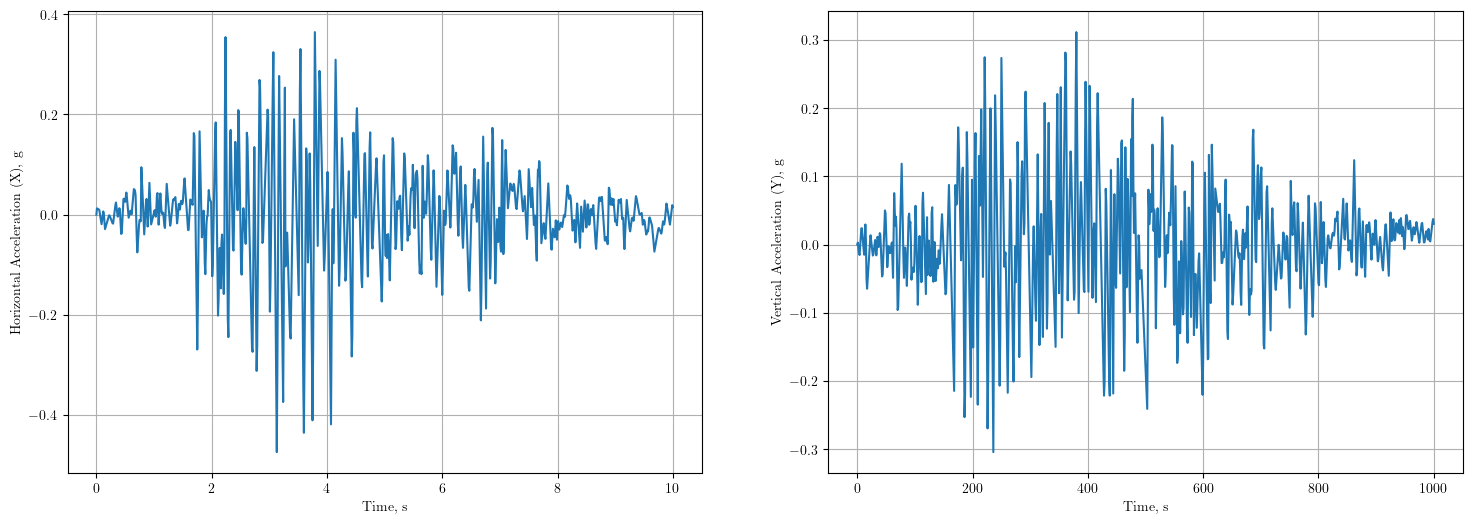

In [15]:
accel_x = np.loadtxt(KOYNA_DIR / 'data' / 'koyna_x_series.txt')
accel_y = np.loadtxt(KOYNA_DIR / 'data' / 'koyna_y_series.txt')

dt_data  = 0.01
n_steps  = len(accel_x)-1
duration = n_steps * dt_data
time     = np.linspace(0,duration,len(accel_x))

print(f'Input duration: {duration:.3f} s')
print(f'Data time step: {dt_data:.3f} s')

fig, ax = plt.subplots(1,2,figsize=(18, 6))
ax[0].plot(time,accel_x)
ax[0].set_xlabel('Time, s')
ax[0].set_ylabel('Horizontal Acceleration (X), g')
ax[0].grid()
ax[1].plot(accel_y);
ax[1].set_xlabel('Time, s')
ax[1].set_ylabel('Vertical Acceleration (Y), g')
ax[1].grid()

The following cell uses the [tqdm](https://tqdm.github.io/) package to print a progress bar. 
If the import fails, the package can be installed by running:

```shell
python -m pip install tqdm
```

In [16]:
from tqdm import tqdm
model.wipeAnalysis()


model.timeSeries('Path', 11, dt=dt_data, values=accel_x, factor=units.gravity)
model.timeSeries('Path', 12, dt=dt_data, values=accel_y, factor=units.gravity)

model.pattern("UniformExcitation", 11, 1, accel=11)
model.pattern("UniformExcitation", 12, 2, accel=12)

model.constraints('Plain')
model.numberer('RCM')
model.system('UmfPack')
model.test('EnergyIncr', 1.0e-12, 3)
model.algorithm('Newton')
model.integrator('Newmark', 0.5, 0.25)
model.analysis('Transient')

dt = 0.005

crest_disp=[model.nodeDisp(crest,1)]
#crest_acc=[model.nodeAccel(crest,1)]

steps = int(duration/dt)
for i in tqdm(range(steps)):
    status = model.analyze(1, dt)
    if status != xara.successful:
            raise RuntimeError(f"analysis failed at time {model.getTime()}")
    crest_disp.append(model.nodeDisp(crest,1))
    #crest_acc.append(model.nodeAccel(crest,1))



100%|██████████| 2000/2000 [00:09<00:00, 208.04it/s]


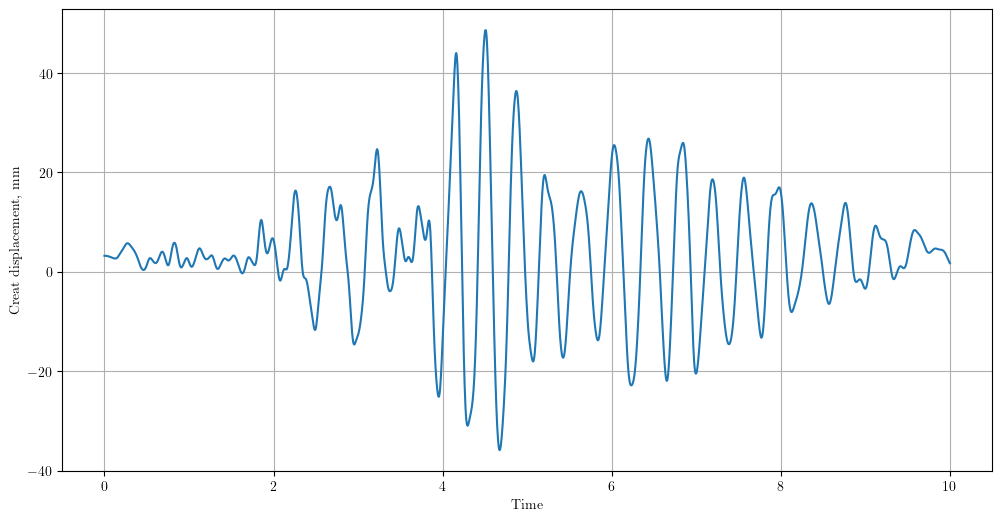

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(np.linspace(0,model.getTime(),len(crest_disp)),np.array(crest_disp)/units.mm)
ax.set_xlabel('Time')
ax.set_ylabel('Creat displacement, mm')
ax.grid(True)